# 5.1: The cross product

Last time, we learned about affine lines and planes in $\mathbb{R}^3$ and different forms of their defining equations. One thing we didn't talk about was converting between different forms of equations for affine planes. This is because it requires a new technique called the **cross product**.

Suppose that we are given a plane $P$ through the origin spanned by the vectors $\vec u$ and $\vec v$. Recall that this allows us to describe position vectors $\vec r$ of points on the plane in the vector-parametric form:
$$ \vec r = t\vec u + s\vec v.$$
How do we convert this into the point-normal form $\vec n \cdot \vec r = 0$? Note that this boils down to finding a vector $\vec n$ that is perpendicular to both $\vec u$ and $\vec v$.

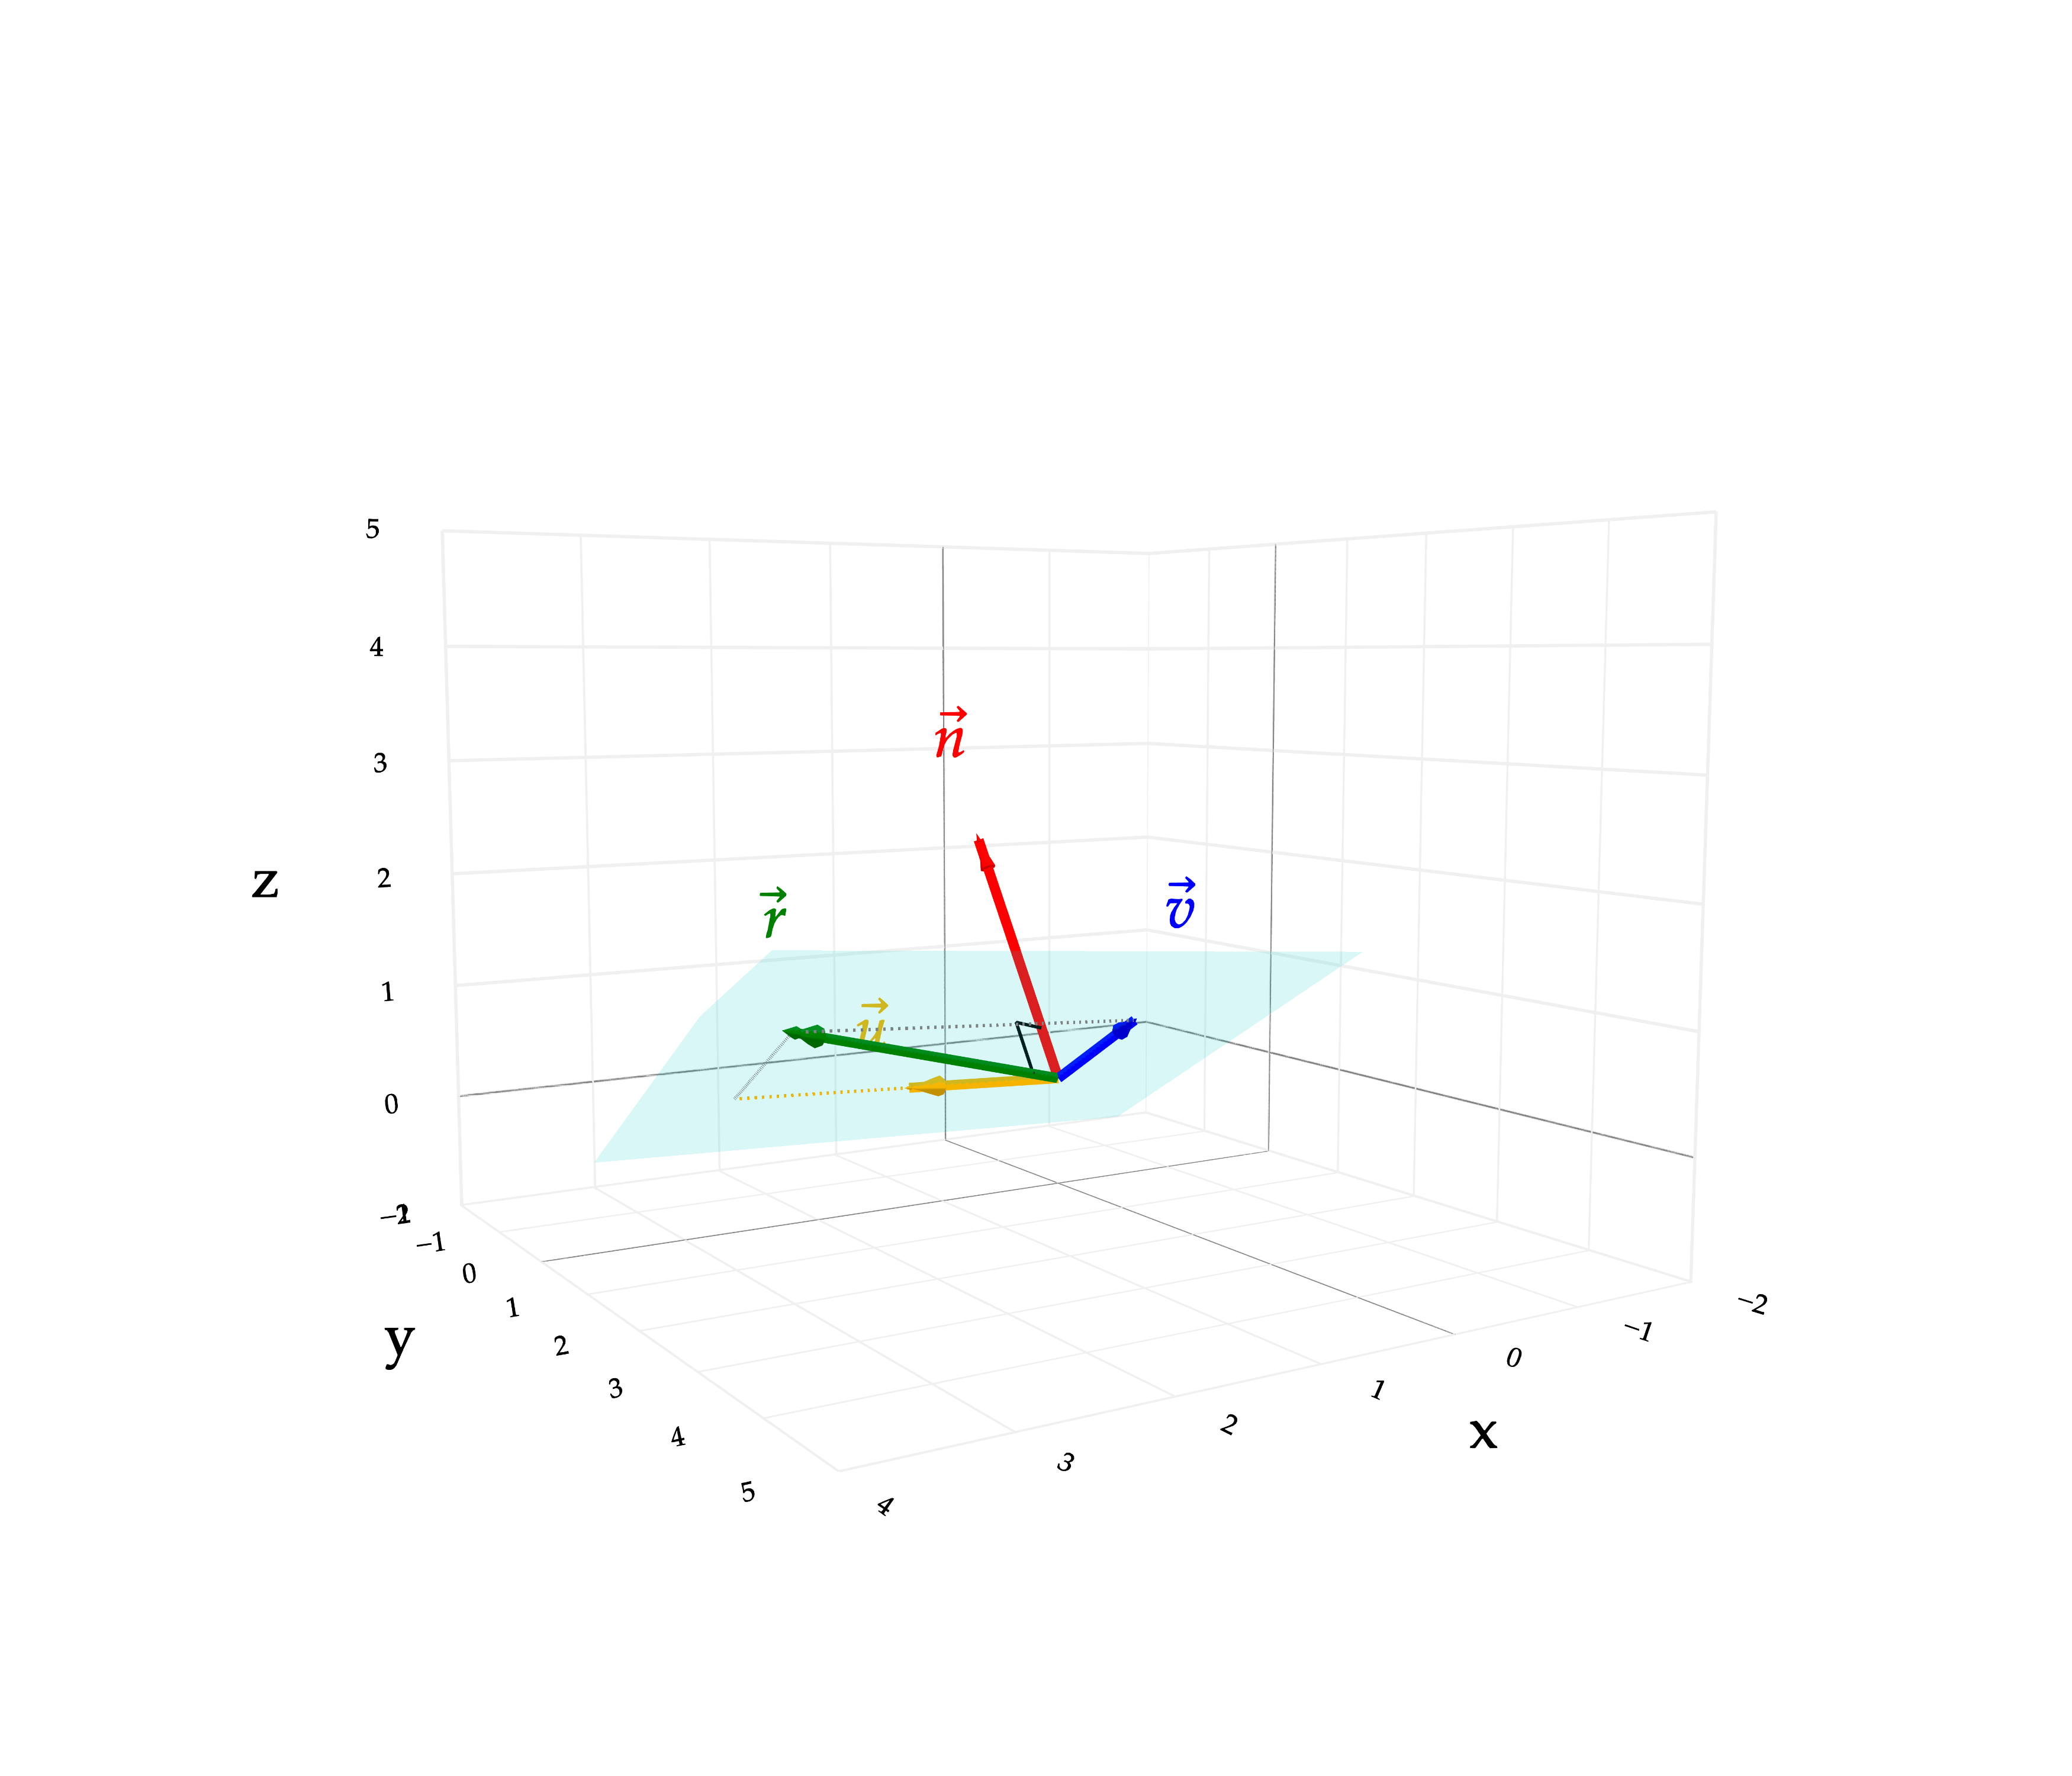

In [3]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the coordinates using numpy arrays
O = np.array([0, 0, 0])
u = np.array([1.5, 0.5, 0.2])
v = np.array([0.2, 1.5, 0.8])

# Position vector on the plane
r = 2*u + 1*v

# Calculate the orthogonal normal vector n
n = np.cross(u, v)

# 1. DEFINE VECTORS (No automatic labels, consistent colors)
vectors = [
    ((tuple(O), tuple(u)), '#f4b400', ''),                 
    ((tuple(O), tuple(v)), 'blue', ''),                
    ((tuple(O), tuple(r)), 'green', ''),
    ((tuple(O), tuple(n)), 'red', '')                    
]

# Generate the base lines
fig = plot_vectors_non_origin(vectors, vdeltax=0, vdeltay=0, vdeltaz=0)

# 2. ADD THE SPANNED PLANE (Semi-transparent)
# Corners sized to frame the 2u + v parallelogram and the origin
c1 = -1.0*u - 1.0*v
c2 =  2.5*u - 1.0*v
c3 =  2.5*u + 2.0*v
c4 = -1.0*u + 2.0*v

fig.add_trace(go.Mesh3d(
    x=[c1[0], c2[0], c3[0], c4[0]],
    y=[c1[1], c2[1], c3[1], c4[1]],
    z=[c1[2], c2[2], c3[2], c4[2]],
    i=[0, 0], j=[1, 2], k=[2, 3],
    color='cyan',
    opacity=0.15,
    showscale=False,
    hoverinfo='skip'
))

# 3. ENHANCE ARROWHEADS
def add_cone(fig, start, end, color):
    fig.add_trace(go.Cone(
        x=[end[0]], y=[end[1]], z=[end[2]],
        u=[end[0]-start[0]], v=[end[1]-start[1]], w=[end[2]-start[2]],
        sizemode="absolute", sizeref=0.3, anchor="tip",
        colorscale=[[0, color], [1, color]], showscale=False, hoverinfo='skip'
    ))

add_cone(fig, O, u, '#f4b400')
add_cone(fig, O, v, 'blue')
add_cone(fig, O, r, 'green')
add_cone(fig, O, n, 'red')

# 4. DRAW THE DECOMPOSITION PARALLELOGRAM
# Dashed line extending u to 2u
fig.add_trace(go.Scatter3d(
    x=[O[0], 2*u[0]], y=[O[1], 2*u[1]], z=[O[2], 2*u[2]],
    mode='lines', line=dict(color='#f4b400', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))
# Closing the parallelogram from 2u to r
fig.add_trace(go.Scatter3d(
    x=[2*u[0], r[0]], y=[2*u[1], r[1]], z=[2*u[2], r[2]],
    mode='lines', line=dict(color='gray', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))
# Closing the parallelogram from v to r
fig.add_trace(go.Scatter3d(
    x=[v[0], r[0]], y=[v[1], r[1]], z=[v[2], r[2]],
    mode='lines', line=dict(color='gray', width=2, dash='dash'), hoverinfo='skip', showlegend=False
))

# 5. DRAW THE RIGHT-ANGLE SYMBOL AT THE ORIGIN
r_hat = r / np.linalg.norm(r)
n_hat = n / np.linalg.norm(n)
square_size = 0.5

# Calculate the corners of the right-angle marker
p1 = O + square_size * r_hat
p2 = p1 + square_size * n_hat
p3 = O + square_size * n_hat

fig.add_trace(go.Scatter3d(
    x=[p1[0], p2[0], p3[0]],
    y=[p1[1], p2[1], p3[1]],
    z=[p1[2], p2[2], p3[2]],
    mode='lines',
    line=dict(color='black', width=2),
    showlegend=False,
    hoverinfo='skip'
))

# 6. MANUAL LABEL POSITIONING (Simplified r label)
label_x = [u[0]+0.2, v[0]-0.2, r[0]+0.2, n[0]+0.1]
label_y = [u[1]-0.2, v[1]+0.3, r[1]+0.2, n[1]-0.3]
label_z = [u[2]-0.2, v[2]+0.3, r[2]+0.3, n[2]+0.2]

label_text = [
    '<i>u</i>\u20D7', 
    '<i>v</i>\u20D7', 
    '<i>r</i>\u20D7', 
    '<i>n</i>\u20D7'
]
label_colors = ['#f4b400', 'blue', 'green', 'red']

fig.add_trace(go.Scatter3d(
    x=label_x, y=label_y, z=label_z,
    mode='text', text=label_text,
    textfont=dict(color=label_colors, size=18),
    showlegend=False, hoverinfo='skip'
))

# Format the 3D layout
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-2, 4], dtick=1),
        yaxis=dict(range=[-2, 5], dtick=1),
        zaxis=dict(range=[-1, 5], dtick=1),
        aspectratio=dict(x=1, y=1, z=0.8)
    )
)

fig.show(scale=5)

## Definition and basic properties

The **cross product** is a tool that allows us to do precisely this task -- it takes two vectors $\vec u, \vec v$ in $\mathbb{R}^3$ and finds a vector that is perpendicular to both of them. Let us write the two vectors as
$$ \vec u = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}, \ \vec v = \begin{bmatrix} y_1 \\ y_2 \\ y_3 \end{bmatrix}.$$
We define the cross product of $\vec u$ and $\vec v$ to be
$$ \vec u \times \vec v = \begin{bmatrix} x_2 y_3 - x_3 y_2 \\ x_3 y_1 - x_1 y_3 \\ x_1 y_2 - x_2 y_1 \end{bmatrix}.$$

Let us list some basic computational properties of the cross product before we dive into its geometric meaning.

#### Non-commutativity
Unlike the usual scalar addition/multiplication or the dot product, the order in which we multiply matters here. Indeed, note that if we put $\vec v$ first instead of $\vec u$, we obtain
$$ \vec v \times \vec u = \begin{bmatrix} y_2 x_3 - y_3 x_2 \\ y_3 x_1 - y_1 x_3 \\ y_1 x_2 - y_2 x_1 \end{bmatrix}$$
which is precisely equal to:
$$ \vec v \times \vec u = - \vec u \times \vec v.$$
This phenomenon, where the order of the operation changes the result, is called _non-commutativity_ in mathematics. Scalar addition/multiplication and the dot product are _commutative_ operations, while scalar subtraction and the cross product are non-commutative.

### Relation with addition and scalar multiplication
The cross product behaves well with addition and scalar multiplication, just like the dot product:
$$ \vec u\times (\vec v + \vec w) = \vec u \times \vec v + \vec u \times \vec w,\quad (\vec u +\vec v) \times \vec w = \vec u \times \vec w + \vec v \times \vec w;$$
$$ t(\vec u \times \vec v) = (t\vec u)\times \vec v = \vec u \times (t\vec v).$$


#### Orthogonality

The geometric significance of the cross product $\vec u\times \vec v$ is that it is orthogonal to both $\vec u$ and $\vec v$. This can be checked using the criterion for orthogonality involving the dot product. Indeed, we see that
$$\begin{align*}
\vec u \cdot (\vec u\times \vec v) &= \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} \cdot \begin{bmatrix} y_2 x_3 - y_3 x_2 \\ y_3 x_1 - y_1 x_3 \\ y_1 x_2 - y_2 x_1 \end{bmatrix} \\
&= x_1(y_2 x_3 - y_3 x_2) + x_2(y_3 x_1 - y_1 x_3) + x_3(y_1 x_2 - y_2 x_1) = 0,
\end{align*}$$
and thus $\vec u\times \vec v$ is orthogonal to $\vec u$. We can similarly check that the cross product is orthogonal to $\vec v$ by using the properties above:
$$ \vec v\cdot (\vec u\times \vec v) = \vec v\cdot (-\vec v\times \vec u) = -\vec v\cdot (\vec v\times \vec u) = 0.$$

#### Right-hand law and magnitude

One part that is unclear now is that there are two different directions that are both orthogonal to $\vec u$ and $\vec v$; in which direction is $\vec u \times \vec v$ pointing? We can find this direction by the **right-hand rule**: placing your index finger on $\vec u$ and your middle finger on $\vec v$, we obtain the direction of $\vec u \times \vec v$ as the direction where your thumb is pointing.

Now that we've discussed the direction of the cross product, it remains to figure out its magnitude. If we let the angle between $\vec u$ and $\vec v$ be $\theta$ (between 0 and 180 degrees), the magnitude turns out to be
$$ \| \vec u \times \vec v\| = \| \vec u \| \| \vec v\| \sin \theta.$$
We won't prove this fact. But one observation worth noting here is that the cross product is zero when $\theta$ is 0 or 180 degrees, i.e. when $\vec u$ and $\vec v$ are parallel to each other.

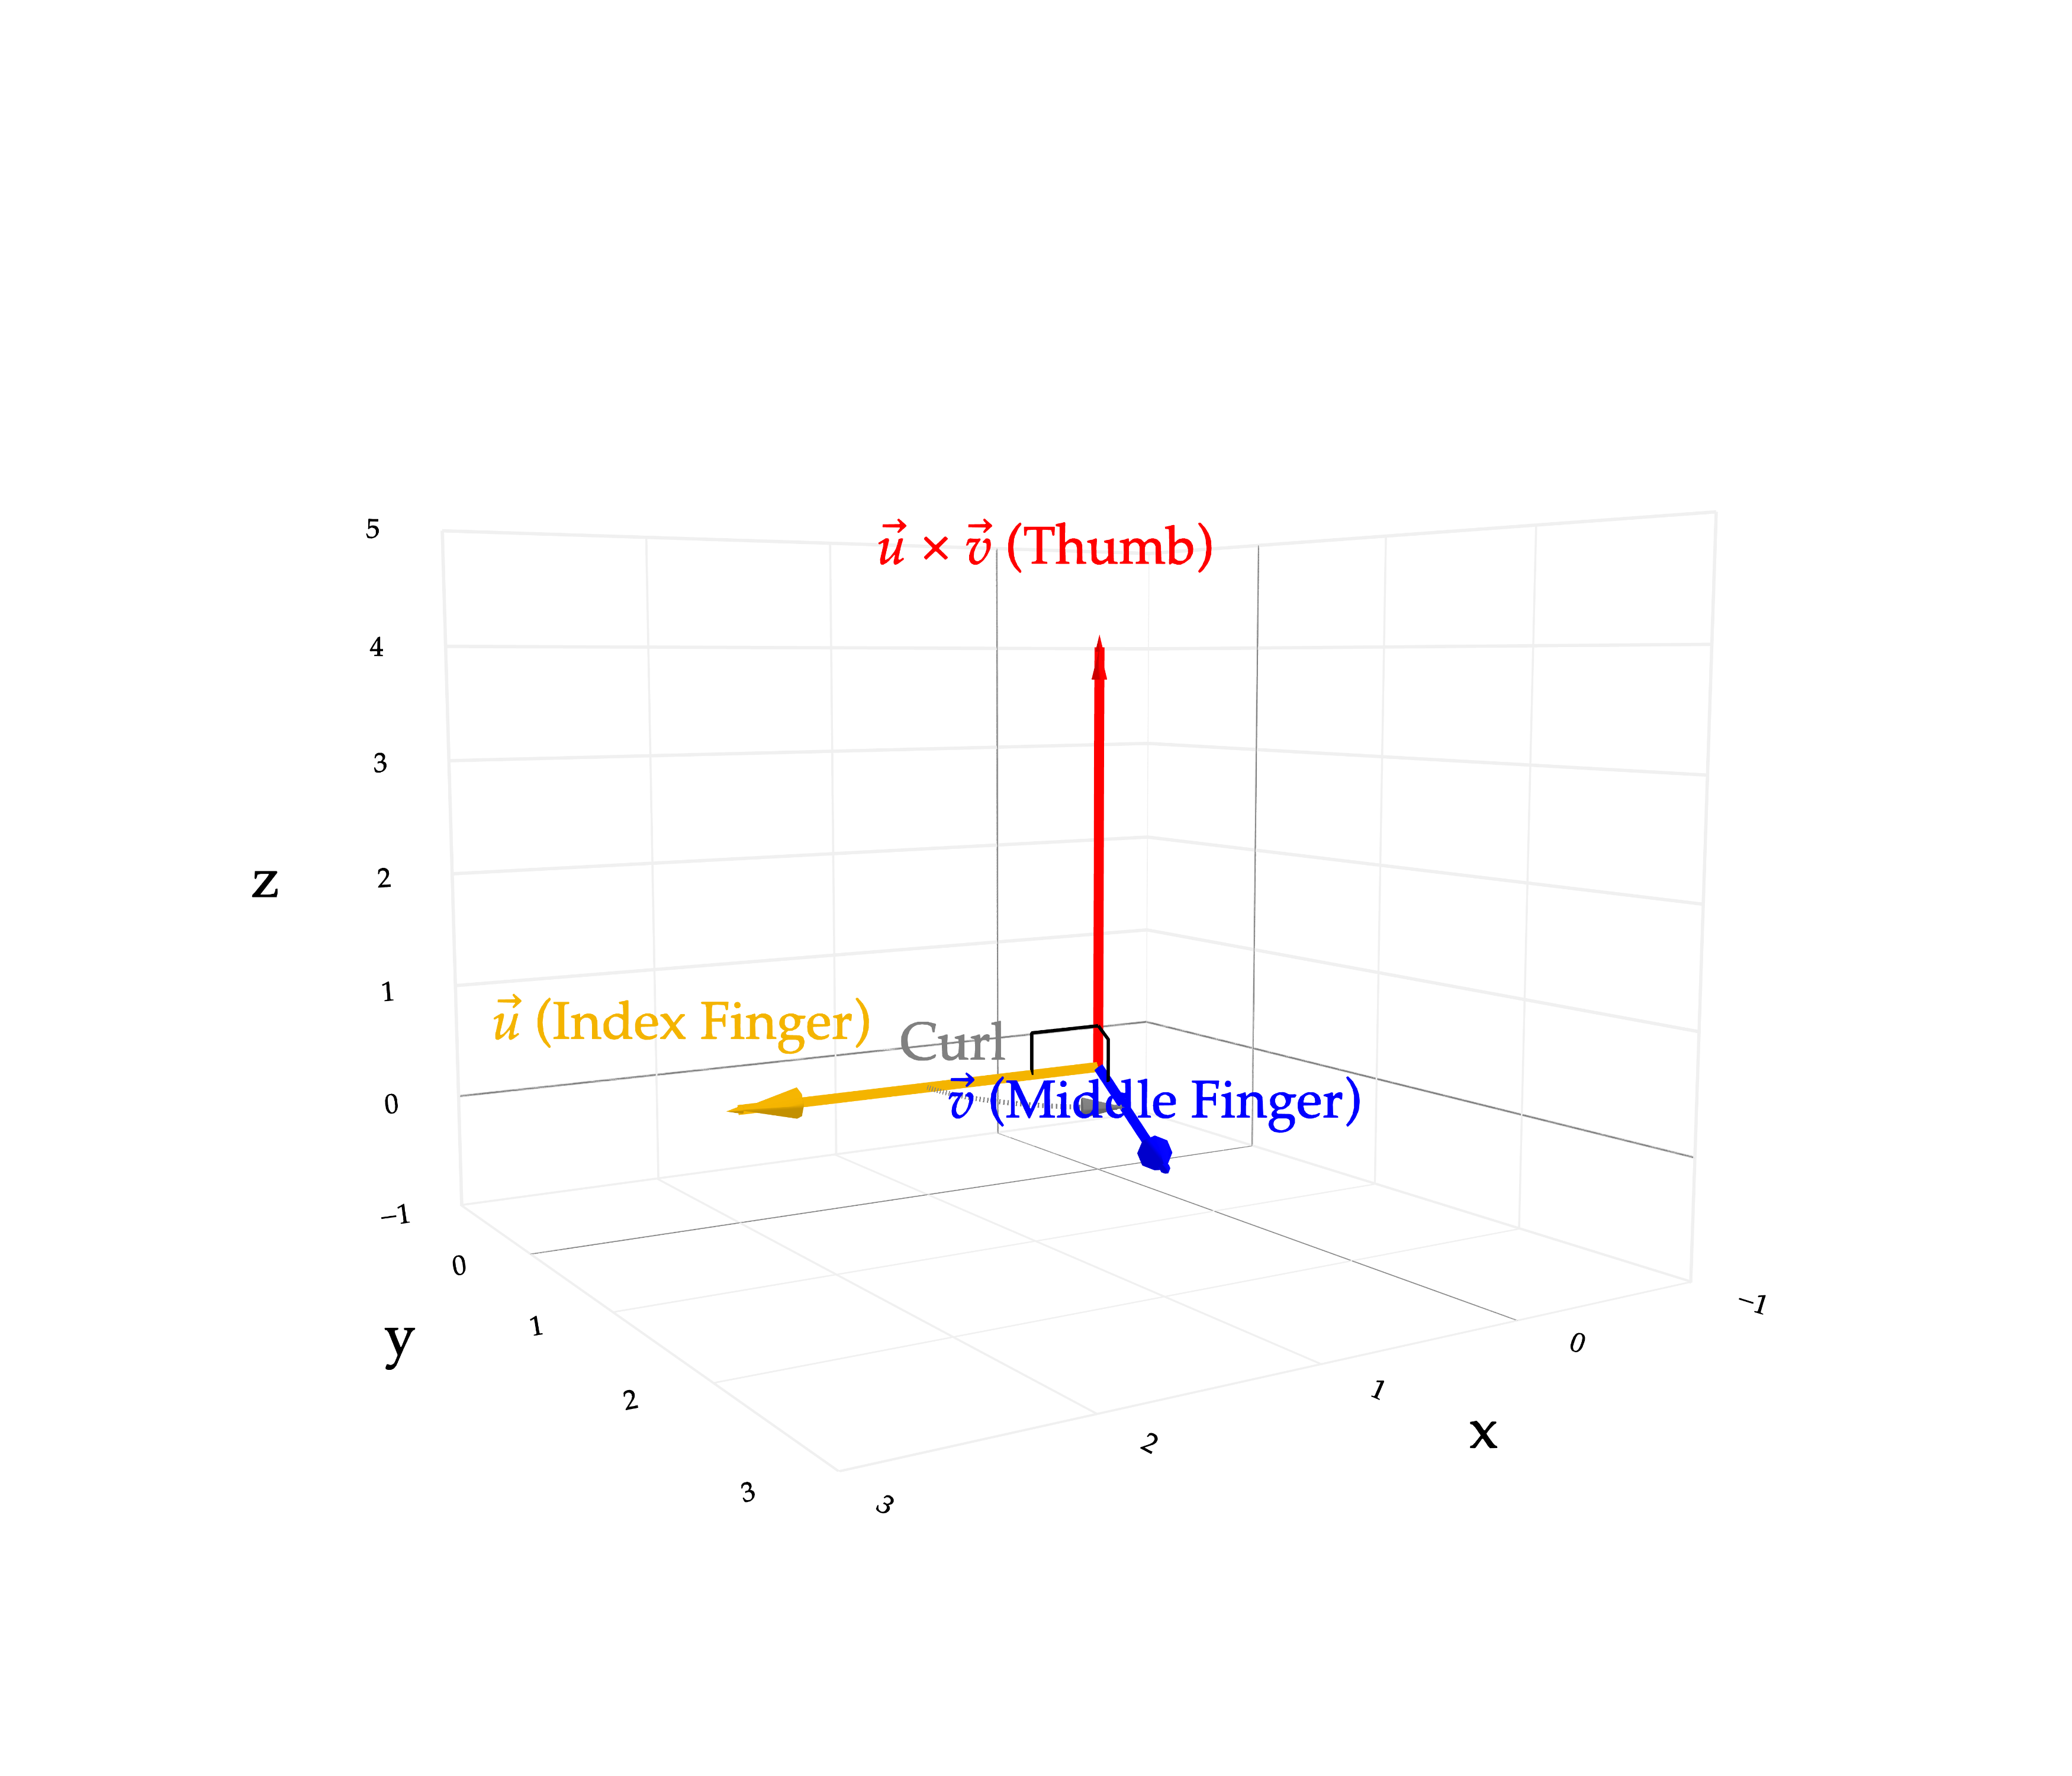

In [10]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# 1. DEFINE VECTORS FOR CLEAR RIGHT-HAND RULE DEMONSTRATION
# We place u and v perfectly flat on the xy-plane (z=0)
O = np.array([0, 0, 0])
u = np.array([2.0, 0.0, 0.0])       # u points strictly along +x
v = np.array([1.0, 2.0, 0.0])       # v points into the +xy quadrant

# The cross product will point strictly UP along the +z axis
cross_uv = np.cross(u, v)

# DEFINE VECTORS (No automatic labels, consistent colors)
vectors = [
    ((tuple(O), tuple(u)), '#f4b400', ''),                 
    ((tuple(O), tuple(v)), 'blue', ''),                
    ((tuple(O), tuple(cross_uv)), 'red', '')                    
]

# Generate the base lines
fig = plot_vectors_non_origin(vectors, vdeltax=0, vdeltay=0, vdeltaz=0)

# 2. ENHANCE ARROWHEADS WITH 3D CONES
def add_cone(fig, start, end, color, size=0.3):
    fig.add_trace(go.Cone(
        x=[end[0]], y=[end[1]], z=[end[2]],
        u=[end[0]-start[0]], v=[end[1]-start[1]], w=[end[2]-start[2]],
        sizemode="absolute", sizeref=size, anchor="tip",
        colorscale=[[0, color], [1, color]], showscale=False, hoverinfo='skip'
    ))

add_cone(fig, O, u, '#f4b400')
add_cone(fig, O, v, 'blue')
add_cone(fig, O, cross_uv, 'red')

# 3. ADD THE "CURL" ARC TO SHOW THE RIGHT HAND RULE
# We draw a curved dashed line from u to v
theta_u = 0
theta_v = np.arctan2(v[1], v[0])
t_vals = np.linspace(theta_u, theta_v, 30)
radius = 1.0

arc_x = radius * np.cos(t_vals)
arc_y = radius * np.sin(t_vals)
arc_z = np.zeros_like(t_vals)

fig.add_trace(go.Scatter3d(
    x=arc_x, y=arc_y, z=arc_z,
    mode='lines',
    line=dict(color='gray', width=3, dash='dash'),
    showlegend=False, hoverinfo='skip'
))

# Add a tiny arrowhead to the end of the arc to show direction
tangent_u = -np.sin(theta_v)
tangent_v = np.cos(theta_v)
fig.add_trace(go.Cone(
    x=[arc_x[-1]], y=[arc_y[-1]], z=[arc_z[-1]],
    u=[tangent_u], v=[tangent_v], w=[0],
    sizemode="absolute", sizeref=0.2, anchor="tip",
    colorscale=[[0, 'gray'], [1, 'gray']], showscale=False, hoverinfo='skip'
))

# 4. DRAW RIGHT-ANGLE SYMBOLS TO SHOW ORTHOGONALITY
square_size = 0.4
z_hat = np.array([0, 0, 1])
u_hat = u / np.linalg.norm(u)
v_hat = v / np.linalg.norm(v)

# Right angle with u
fig.add_trace(go.Scatter3d(
    x=[square_size*u_hat[0], square_size*u_hat[0], 0],
    y=[square_size*u_hat[1], square_size*u_hat[1], 0],
    z=[0, square_size, square_size],
    mode='lines', line=dict(color='black', width=2), showlegend=False, hoverinfo='skip'
))
# Right angle with v
fig.add_trace(go.Scatter3d(
    x=[square_size*v_hat[0], square_size*v_hat[0], 0],
    y=[square_size*v_hat[1], square_size*v_hat[1], 0],
    z=[0, square_size, square_size],
    mode='lines', line=dict(color='black', width=2), showlegend=False, hoverinfo='skip'
))

# 5. MANUAL LABEL POSITIONING
label_x = [u[0]+0.2, v[0]+0.2, cross_uv[0]+0.2, 1.2]
label_y = [u[1]-0.2, v[1]+0.2, cross_uv[1]-0.2, 0.6]
label_z = [u[2], v[2], cross_uv[2]+0.2, 0]

label_text = [
    '<i>u</i>\u20D7 (Index Finger)', 
    '<i>v</i>\u20D7 (Middle Finger)', 
    '<i>u</i>\u20D7 \u00D7 <i>v</i>\u20D7 (Thumb)',
    'Curl'
]
label_colors = ['#f4b400', 'blue', 'red', 'gray']

fig.add_trace(go.Scatter3d(
    x=label_x, y=label_y, z=label_z,
    mode='text', text=label_text,
    textfont=dict(color=label_colors, size=16),
    showlegend=False, hoverinfo='skip'
))

# 6. FORMAT 3D LAYOUT (Axes restored for orientation!)
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-1, 3], dtick=1, title='x'),
        yaxis=dict(range=[-1, 3], dtick=1, title='y'),
        zaxis=dict(range=[-1, 5], dtick=1, title='z'),
        aspectratio=dict(x=1, y=1, z=0.8)
    )
)

fig.show(scale=5)

## Different forms of the plane

Suppose we are given a plane $P$ through the origin given by the span of $\vec u$ and $\vec v$, expressed by the vector-parametric form
$$ \vec r = t\vec u + s\vec v.$$
We can now convert this into the point-normal form using the cross product; we simply take the normal vector as $\vec n = \vec u \times \vec v$ and write
$$ \vec n \cdot \vec r =  0.$$

Similarly, given an affine plane spanned by $\vec u$ and $\vec v$ and goes through $\vec p$, given by
$$ \vec r = \vec p + t \vec u + s\vec v,$$
we can convert this into point-normal form as
$$ \vec n \cdot (\vec r - \vec p) = 0$$
where $\vec n = \vec u \times \vec v$.

### Example
 Consider the plane spanned by $e_1$ and $e_2$ in $\mathbb{R}^3$. This is the $xy$-plane. Taking the cross product,
    $$ \vec n = \vec e_1 \times \vec e_2 = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix} \times \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix} = \vec e_3,$$
    i.e. the normal vector $\vec n$ is pointing in the positive $z$-direction. Expanding out the point-normal form
    $$\vec n \cdot \vec e_3 = 0,$$
    we obtain the Cartesian form of the plane as 
    $$z = 0.$$

